In [34]:
from sklearn.datasets import make_regression 
import numpy as np 
import torch
from sklearn.model_selection import train_test_split
import random

In [35]:
import torch

# this is single feature dataset
x, y = make_regression(
    n_samples=100,
    n_features=1,
    noise=20,
    random_state=42
)

# make_regression returns numpy arrays -> convert to torch tensors
x = torch.tensor(x, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

# starting guess for the line: y = w*x + b
w = torch.tensor(2.0)   # weight (slope)
b = torch.tensor(3.0)   # bias  (intercept)

print(x.shape)
print(y.shape)

torch.Size([100, 1])
torch.Size([100])


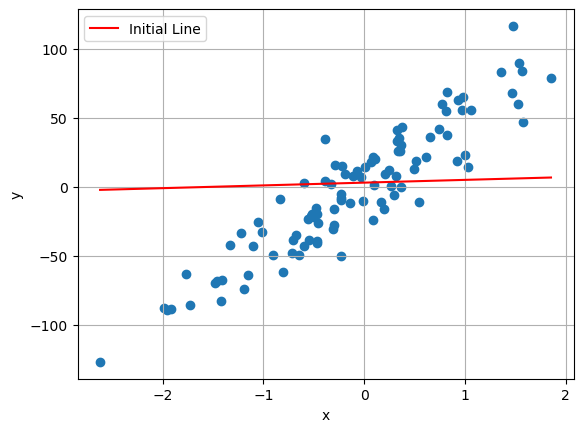

In [36]:
import matplotlib.pyplot as plt

# scatter = all 100 real data points (the dots)
plt.scatter(x.numpy(), y.numpy())

# ---------------------------------------------------------------------------
# Drawing the guess line  y = w*x + b
#
# A straight line is fully defined by just TWO points. So instead of computing
# y for all 100 x's, we only take the LEFT edge (min x) and RIGHT edge (max x),
# find the line's height (y) at each, and let matplotlib connect them.
#
#   x_ends = [min x , max x]        <- the two edge x-values
#   y_ends = w * x_ends + b         <- line height at each edge
#
#        y |              ● (max x , y_ends[1])
#          |           
#          |                <- plt.plot draws ONE straight line
#          |                  between these two dots
#          |  ● (min x , y_ends[0])
#          +-------------------- x
#
# (the dots from scatter sit underneath; this red line is our w,b guess)
# ---------------------------------------------------------------------------
x_ends = torch.tensor([x.min().item(), x.max().item()])
y_ends = w * x_ends + b 

plt.plot(x_ends.numpy(), y_ends.numpy(), 'r', label='Initial Line')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def SGD(Loss, W, B, X_k):
    """ 
    let w, b be defined as A
    
    A_k+1 = A_k + learning_rate_k * gradient(f_i k) 
    Here, k defines the randomly choosen indexes for dataset

    Here, we only have a single feature so we don't have to randomize weight and bias. 
    If we had multiple features, which would produce multiple weight and bias we'd need to randomize weight and bias
    
    # *** also we have to randomize learning rate *** 

    gradient = gradient(f_i(xK))

    For MSE, the gradient would be 
    Loss = (y_pred - y_train) ^2 
    Loss = ( w . x_k + b - y_train ) // Expanding the equation 
        Note : Here, x_k represents random data we choose. 
               It's defined as x_batch in training loop.

    With Respect to Weight: 
    ∂Loss / ∂w = 2 (w . x_k + b - y_train) * x_k 
    
    With Respect to Bias: 
    ∂Loss / ∂b = 2 (w . x_k + b - y_train) * 1

    Therefore: 
    grad_w = 2 (loss) * x_k 
    grad_b = 2 (loss) * 1 

    """
    
    lr = 0.01 # randomize this to a specific bound

    grad_W = 2 * (Loss) * X_k
    grad_B = 2 * (Loss) * 1

    W_new = W - lr * grad_W
    B_new = B - lr * grad_B

    return W_new, B_new 
    
    



y = y.reshape(100,1)
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2)
loss_indx = []

for i in range(100):
# Here's how the training loop will work 
    # 1. From x_train, find random set of point x and y
            # k = randint(1,len(x_train)) // bounding the random number to be less than the training set
            # then --> taking x_train[:k]
    # 2. Also when you take x_train also don't forget to take y_train 
        # define randomized values as x_batch, and y_batch
    # 3. Calculate y_pred , w * x_batch + b
    # 4. Calcualte loss 
        # loss = y_pred - y_train
    # 5. Send into SGD function which calcualtes updated weight and bias 
    # 6. update weight and bias 
    # 7. Repeat this loop 

    # 1's Implementation (1 is defined above): 



    # k defined to pick a random batch size for each iteration
    k = random.randint(1, len(x_train)-1)

    # extract the x and y values from the shuffled pairs 
    # zip() converts tensors to tuples so we'd need to turn the flipped value back into tensors
    x_batch = x_train[k]
    y_batch = y_train[k]

    # f_i for x~P 
    y_pred = w * x_batch + b

    # g(f_i, x, y)  -> signed residual, this feeds the gradient
    loss = y_pred - y_batch

    # save the SQUARED loss as a plain number so we can plot it per step
    loss_indx.append((loss ** 2).item())


    # perform SGD
    new_w, new_b = SGD(loss, w, b, x_batch)

    # update weight and bias 
    w = new_w 
    b = new_b 


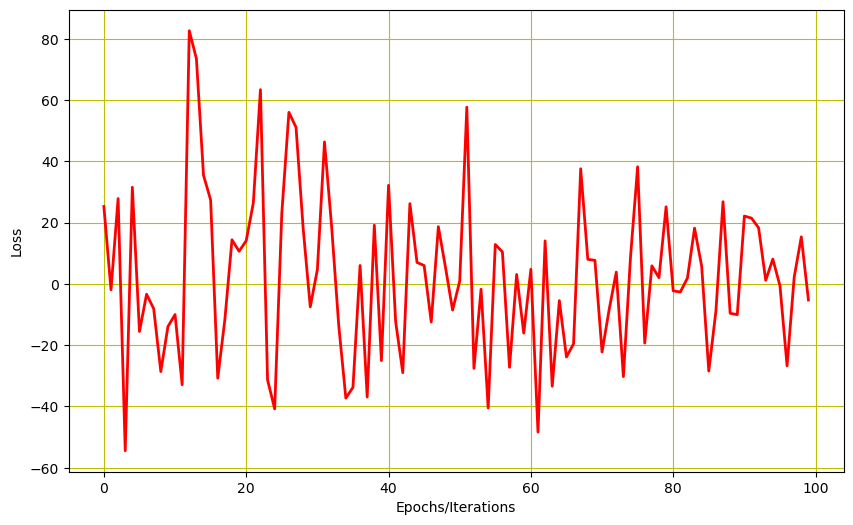

In [43]:
# loss_indx holds the squared loss at each SGD step (filled in the loop above)
plt.figure(figsize=(10, 6))
plt.plot(loss_indx, 'r', lw=2)
plt.xlabel('Epochs/Iterations')
plt.ylabel('Loss')
plt.grid(True, color='y')
plt.show()

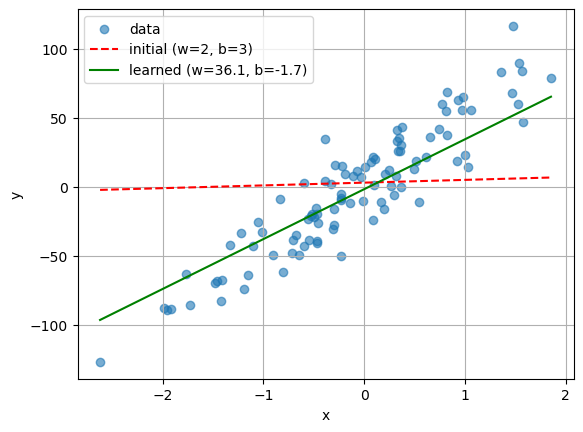

In [44]:
# final fit: data + the line SGD learned
x_ends = torch.tensor([x.min().item(), x.max().item()])

plt.scatter(x.numpy(), y.numpy(), alpha=0.6, label='data')
plt.plot(x_ends.numpy(), (2.0 * x_ends + 3.0).numpy(), 'r--', label='initial (w=2, b=3)')
plt.plot(x_ends.numpy(), (w * x_ends + b).numpy(), 'g', label=f'learned (w={w.item():.1f}, b={b.item():.1f})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
# compare my SGD to sklearn's SGDRegressor
from sklearn.linear_model import SGDRegressor

# Sklearn's SGD
ref = SGDRegressor(penalty=None).fit(x.numpy(), y.numpy().ravel())

print(f"my SGD:   w={w.item():.2f}  b={b.item():.2f}")
print(f"sklearn:  w={ref.coef_[0]:.2f}  b={ref.intercept_[0]:.2f}")

my SGD:   w=36.12  b=-1.72
sklearn:  w=47.09  b=2.31
